# Proper Orthogonal Decomposition (POD) of a turbulent airfoil wake

This notebook shows how to apply POD to a fluid dynamics problem.
The dataset used here corresponds to transient results of a Large Eddy Simulation (LES) of a turbulent airfoil wake at a Reynolds number of 23,000.
The dataset is freely available online in [1].
Here we analyze snapshots collected at the airfoil midspan over time.

For a background of POD in the context of SVD-ROM, refer to the [docs](https://svdrom.readthedocs.io/en/latest/contents/background.html#proper-orthogonal-decomposition).

**References**

[1] Towne, A., Yeh, C., Patel, H., Taira, K. (2022). Turbulent airfoil wake large eddy simulation [Data set], University of Michigan - Deep Blue Data. https://doi.org/10.7302/0e3g-6j84

## 1. Downloading and preparing the dataset

Go to the [dataset website](https://doi.org/10.7302/0e3g-6j84) and download `airfoilLES_snapshots_midspan.zip` (35.6 GB), `airfoilLES_grid.h5` (5 MB) and `airfoilLES_parameters.h5` (2 KB).
The Zip file contains snapshots collected over time on an unstructured 2D grid.
The snapshots are saved as separate HDF5 files, one for each time step.
`airfoilLES_grid.h5` contains information about the grid.
`airfoilLES_parameters.h5` contains temporal information as well as the Reynolds number.
Note that all data has been non-dimensionalized.

To enable fast IO and efficient application of SVD-ROM to the dataset, as a pre-processing step we can combine the multi-file dataset into a single chunked Zarr store.

To do so, you can run the `convert_airfoilLES_to_zarr.py` script. All paths used by the script and by this notebook are relative to the `demos/` directory, so run it from there:

```bash
cd demos
uv run --extra demos convert_airfoilLES_to_zarr.py
```

The script expects the downloaded files under `demos/data/airfoilLES/` and writes the Zarr store to `demos/data/airfoilLES/airfoilLES_midspan.zarr`. Modify the dataset paths defined at the top of the script if your layout differs. Start Jupyter from the `demos/` directory as well, so the relative paths in the cells below resolve.


## 2. Preliminary analysis

Let's make some plots of the dataset we are going to analyze.
We will plot the time averaged flow field, as well as a couple of snapshots in order to visualize the turbulent wake behind the airfoil.

In [1]:
from __future__ import annotations

import os
import tempfile

import numpy as np
import xarray as xr
from dask.distributed import Client
from matplotlib import pyplot as plt

from svdrom.preprocessing import StandardScaler


Open the Zarr store we just created.

In [2]:
data = xr.open_zarr("data/airfoilLES/airfoilLES_midspan.zarr", chunks="auto")

As shown below, the dataset contains 3 variables (x-, y- and z-components of velocity) on an unstructured grid defined by the `x` and `y` coordinates.
The data has dimensions `time` (we have 16,000 snapshots) and `point` (the unstructured grid containing 222,210 spatial locations).
There is an additional coordinate called `w` which provides the volume associated with each grid point.

In [3]:
data

<xarray.Dataset> Size: 43GB
Dimensions:  (time: 16000, point: 222210)
Coordinates:
  * time     (time) float64 128kB 0.0 0.01035 0.0207 ... 165.6 165.6 165.6
  * point    (point) int64 2MB 0 1 2 3 4 ... 222205 222206 222207 222208 222209
    x        (point) float64 2MB dask.array<chunksize=(222210,), meta=np.ndarray>
    y        (point) float64 2MB dask.array<chunksize=(222210,), meta=np.ndarray>
    w        (point) float64 2MB dask.array<chunksize=(222210,), meta=np.ndarray>
Data variables:
    uy       (time, point) float32 14GB dask.array<chunksize=(100, 222210), meta=np.ndarray>
    uz       (time, point) float32 14GB dask.array<chunksize=(100, 222210), meta=np.ndarray>
    ux       (time, point) float32 14GB dask.array<chunksize=(100, 222210), meta=np.ndarray>

In [4]:
print(f"Dataset size: {data.nbytes / (1024)**3:.2f} GiB")

Dataset size: 39.74 GiB


Before we begin any computations, let's start a Dask local multi-threaded cluster.
Since we are dealing with Dask arrays whose chunks are composed of NumPy arrays, a multi-threaded cluster works well because NumPy will release the GIL, which will allow parallel work.

Here we are using an Azure VM with 8 cores and 32 GB of RAM.
We have attached a 1 TB SSD to the VM, mounted on `/data`.
Dask may need to spill to disk, so it is worth pointing it at a fast local disk. The cell below reads the spill location from the `DASK_SPILL_DIR` environment variable and falls back to the system temporary directory, so set `DASK_SPILL_DIR` to a path on a fast disk before starting Jupyter (we used `/data/dask_spill` on the attached SSD).


In [5]:
dask_spill_folder = os.environ.get("DASK_SPILL_DIR", tempfile.gettempdir())
client = Client(processes=False, local_directory=dask_spill_folder)


You can access the Dask dashboard at http://localhost:8787/status to monitor the computations.

In [6]:
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://10.10.0.4:8787/status,
Dashboard: http://10.10.0.4:8787/status,Workers: 1
Total threads: 8,Total memory: 31.29 GiB
Status: running,Using processes: False
Comm: inproc://10.10.0.4/8150/1,Workers: 0
Dashboard: http://10.10.0.4:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: inproc://10.10.0.4/8150/4,Total threads: 8
Dashboard: http://10.10.0.4:44881/status,Memory: 31.29 GiB
Nanny: None,


Let's now calculate the time-averaged flow field so that we can plot it.

In [7]:
scaler = StandardScaler()
scaler(data)

2026-08-04 13:44 - Preprocessing - INFO - Computing mean along dimension time...
2026-08-04 13:47 - Preprocessing - INFO - Finished computing mean.


<xarray.Dataset> Size: 43GB
Dimensions:  (point: 222210, time: 16000)
Coordinates:
  * point    (point) int64 2MB 0 1 2 3 4 ... 222205 222206 222207 222208 222209
    x        (point) float64 2MB -0.5425 -0.5312 -0.5226 ... 6.067 6.067 6.067
    y        (point) float64 2MB -2.254 -2.039 -1.84 ... 2.081 2.199 2.323
    w        (point) float64 2MB 0.006112 0.005349 0.00476 ... 0.008718 0.008935
  * time     (time) float64 128kB 0.0 0.01035 0.0207 ... 165.6 165.6 165.6
Data variables:
    uy       (time, point) float32 14GB dask.array<chunksize=(100, 222210), meta=np.ndarray>
    uz       (time, point) float32 14GB dask.array<chunksize=(100, 222210), meta=np.ndarray>
    ux       (time, point) float32 14GB dask.array<chunksize=(100, 222210), meta=np.ndarray>

The time-averaged velocity components are returned as (in-memory) NumPy arrays.
This is because they have no time dimension and are therefore relatively small and easy to store in memory.

In [8]:
scaler.mean

<xarray.Dataset> Size: 10MB
Dimensions:  (point: 222210)
Coordinates:
  * point    (point) int64 2MB 0 1 2 3 4 ... 222205 222206 222207 222208 222209
    x        (point) float64 2MB -0.5425 -0.5312 -0.5226 ... 6.067 6.067 6.067
    y        (point) float64 2MB -2.254 -2.039 -1.84 ... 2.081 2.199 2.323
    w        (point) float64 2MB 0.006112 0.005349 0.00476 ... 0.008718 0.008935
Data variables:
    uy       (point) float32 889kB -0.0003774 -0.0001025 ... -0.008489 -0.008397
    uz       (point) float32 889kB 1.19e-12 1.26e-11 ... 1.468e-10 1.937e-10
    ux       (point) float32 889kB 0.983 0.9815 0.9799 ... 1.003 1.003 1.003

The cell below plots the x-velocity time average.
The velocity has been non-dimensionalized relative to the free stream velocity.
For simplicity, we plot it as a colored scatter plot since the data is defined on an unstructured grid.
Note that the grid is much finer in the `-1 < y < 1` region since this is where most of the interesting aerodynamics are taking place.
We can clearly see that the flow moves left to right, it accelerates over the upper surface (suction side with lower static pressure) of the airfoil, which has a non-trivial angle of attack, and eventually separates resulting in a wake of low-velocity flow downstream of the airfoil.

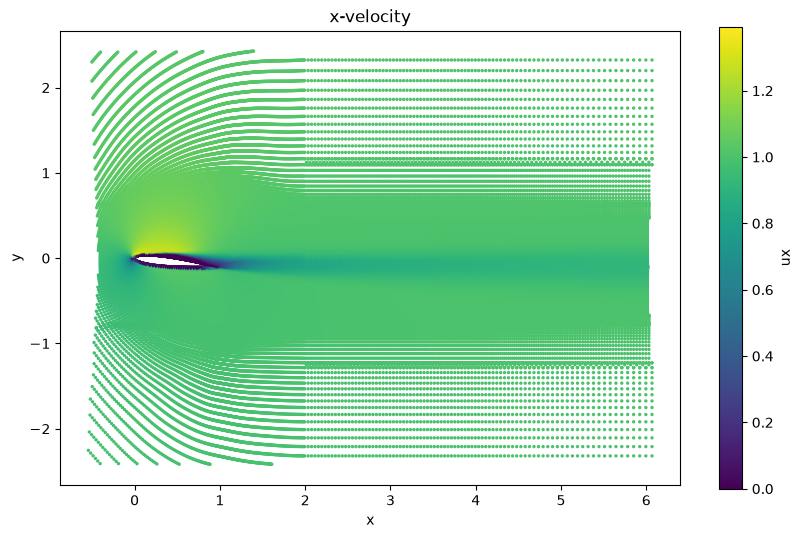

In [9]:
ux, x, y = scaler.mean["ux"], scaler.mean["x"], scaler.mean["y"]
fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(x, y, c=ux, s=2, cmap="viridis", vmin=0, vmax=ux.max())
fig.colorbar(sc, ax=ax, label="ux")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("x-velocity")
ax.set_aspect("equal")
plt.show()

The cell below plots two different snapshots of the x-velocity in the `-1 < y < 1` region.
We can clearly see vortex shedding behind the airfoil.
This is the phenomenon we will try to capture with POD.

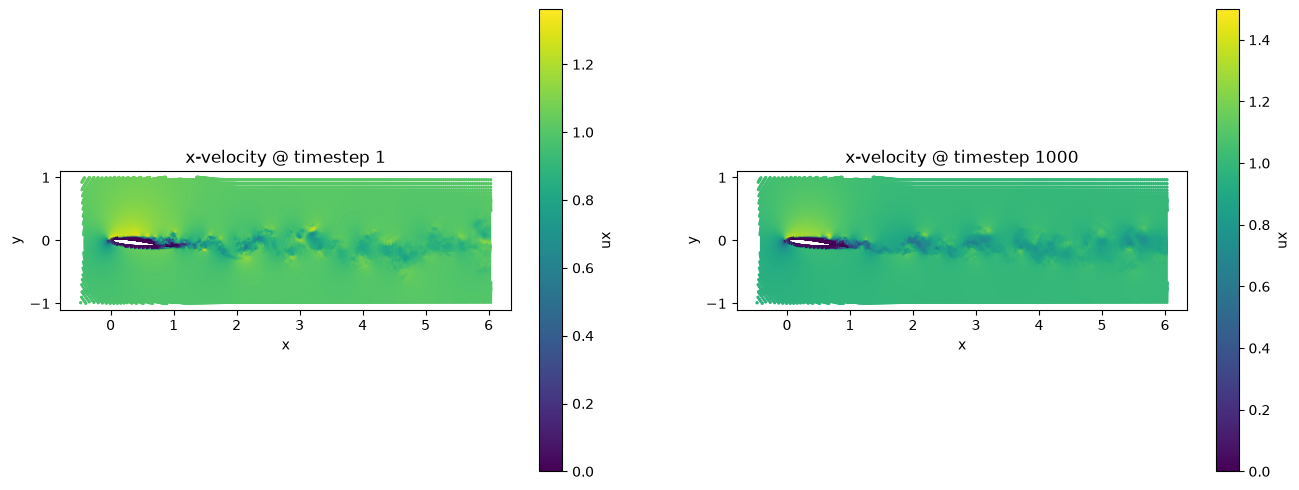

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

time_step = 0
ux = data["ux"].isel(time=time_step).compute()
mask = (ux.y >= -1) & (ux.y <= 1)
ux = ux.where(mask, drop=True)
x, y = x.where(mask, drop=True), y.where(mask, drop=True)
ax = axes[0]
sc = ax.scatter(x, y, c=ux, s=2, cmap="viridis", vmin=0, vmax=ux.max())
fig.colorbar(sc, ax=ax, label="ux")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title(f"x-velocity @ timestep {time_step+1}")
ax.set_aspect("equal")

time_step = 999
ux = data["ux"].isel(time=time_step).compute()
mask = (ux.y >= -1) & (ux.y <= 1)
ux = ux.where(mask, drop=True)
x, y = x.where(mask, drop=True), y.where(mask, drop=True)
ax = axes[1]
sc = ax.scatter(x, y, c=ux, s=2, cmap="viridis", vmin=0, vmax=ux.max())
fig.colorbar(sc, ax=ax, label="ux")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title(f"x-velocity @ timestep {time_step+1}")
ax.set_aspect("equal")

plt.show()

To confirm if oscillating flow is present downstream of the airfoil as a result of vortex shedding, the cell below computes and plots the power spectrum of the y-component of velocity at approximately `x=2, y=0`.
Because time is non-dimensionalized, the power spectrum is plotted as a function of Strouhal number (non-dimensional frequency).
The plot suggests there is an oscillatory component in the velocity signal at $St \approx 1.5$.

/data/davidsj/repos/svdrom/.venv/lib/python3.12/site-packages/xarray/core/dataarray.py:6325: FutureWarning: Behaviour of argmin/argmax with neither dim nor axis argument will change to return a dict of indices of each dimension. To get a single, flat index, please use np.argmin(da.data) or np.argmax(da.data) instead of da.argmin() or da.argmax().
  result = self.variable.argmin(dim, axis, keep_attrs, skipna)


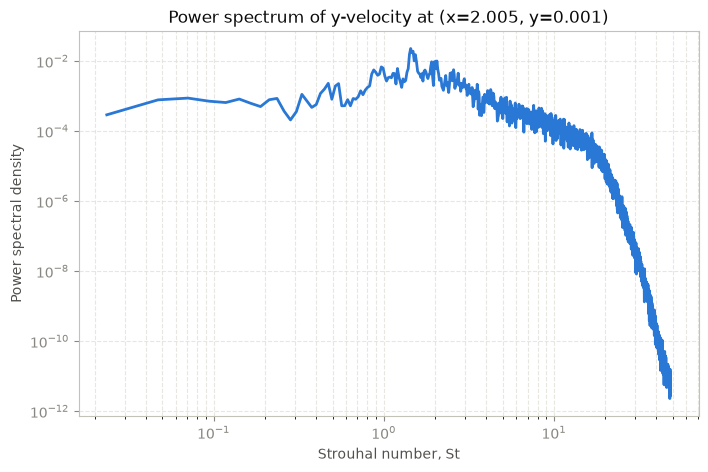

In [ ]:
from scipy.signal import welch

x0, y0 = 2.0, 0.0
dist2 = (data.x - x0) ** 2 + (data.y - y0) ** 2
point_idx = int(dist2.compute().argmin())

uy_ts = data["uy"].isel(point=point_idx).compute()
x_pt, y_pt = float(data.x[point_idx]), float(data.y[point_idx])

t = data["time"].values
dt = np.mean(np.diff(t))
fs = 1.0 / dt

f, Pxx = welch(uy_ts.values, fs=fs, nperseg=4096)

fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(f[1:], Pxx[1:], color="#2a78d6", linewidth=2)
ax.set_xlabel("Strouhal number, St", color="#52514e")
ax.set_ylabel("Power spectral density", color="#52514e")
ax.set_title(
    f"Power spectrum of y-velocity at (x={x_pt:.3f}, y={y_pt:.3f})",
    color="#0b0b0b",
)
ax.grid(True, which="both", ls="--", color="#e1e0d9", alpha=0.8)
ax.tick_params(colors="#898781")
for spine in ax.spines.values():
    spine.set_color("#c3c2b7")
plt.show()

## 3. POD of velocity field

We will now perform POD on the x- and y-velocity components simultaneously.
We will do so on the fluctuations about the time average, as is typically done in POD.
This prevents the POD from capturing the time-averaged flow field, so that it fully focuses on the energetic turbulent fluctuations.

We will use the `variable_spatial_stack()` function from the `svdrom.preprocessing` module to build the matrix on which we will perform POD.
This function will stack the `point` dimension and the x-velocity and y-velocity variables along a new `samples` dimension.
By doing so, we obtain a new matrix with dimensions `(samples, time)`.

Note that there's nothing preventing us from also using z-velocity component, but using the x- and y-velocity components are probably the most informative to capture the oscillatory flow we are interested in.
Because we decompose only the in-plane components, the energy fractions reported below are shares of the in-plane (`ux`, `uy`) fluctuation energy, not of the full three-component turbulent kinetic energy, which would require including `uz`.


In [12]:
from svdrom.pod import POD
from svdrom.preprocessing import variable_spatial_stack

As discussed above, the region of interest is the `-1 < y < 1` region, so we will restrict the dataset to this region before stacking the variables.

In [13]:
u_xy = data.drop_vars("uz")
mask = ((u_xy.y >= -1) & (u_xy.y <= 1)).compute()
u_xy = u_xy.where(mask, drop=True)
u_xy = variable_spatial_stack(u_xy, dims=["point"]).T

2026-08-04 13:47 - Preprocessing - INFO - Performing variable stacking.
2026-08-04 13:47 - Preprocessing - INFO - Performing spatial stacking.


This is the array on which we will perform POD, with dimensions `(samples, time)`.
It has approximately 400,000 rows and 16,000 columns, so it is strongly tall and skinny.
Dropping the z-velocity component, it has an approximate size of 25 GiB.

In [14]:
u_xy

<xarray.DataArray (samples: 411232, time: 16000)> Size: 26GB
dask.array<transpose, shape=(411232, 16000), dtype=float32, chunksize=(205616, 100), chunktype=numpy.ndarray>
Coordinates:
  * samples   (samples) object 3MB MultiIndex
    x         (samples) float64 3MB -0.4758 -0.4604 -0.458 ... 6.031 6.031 6.031
    y         (samples) float64 3MB -0.9895 -0.9028 -0.7032 ... 0.9013 0.9625
    w         (samples) float64 3MB 0.002413 0.002155 ... 0.002113 0.002301
  * variable  (samples) object 3MB 'uy' 'uy' 'uy' 'uy' ... 'ux' 'ux' 'ux' 'ux'
  * point     (samples) int64 3MB 23 43 47 50 55 ... 222169 222170 222171 222172
  * time      (time) float64 128kB 0.0 0.01035 0.0207 ... 165.6 165.6 165.6

Let's create a POD instance.
We will request 10 modes, which should be sufficient to capture the oscillatory flow in the wake of the airfoil.
We will use the randomized SVD algorithm, which is highly memory efficient for large matrices with a non-negligible number of columns.
Note that the `POD` class has a `remove_mean` parameter that defaults to `True`, which will remove the time-average prior to fitting the POD on the data.

In [15]:
pod = POD(
    n_modes=10,
    svd_algorithm="randomized",
    compute_energy_ratio=True,
)

As discussed in the SVD demo notebooks, we can use oversamples and power iterations to improve the accuracy of the randomized SVD algorithm.
As we can see, we can compute the time-average and the first 10 POD modes of a 25 GB dataset in under 10 minutes in a 8-core, 32 GB machine.

In [16]:
pod.fit(u_xy, n_oversamples=15, n_power_iter=2)

2026-08-04 13:47 - Preprocessing - INFO - Computing mean along dimension time...
2026-08-04 13:47 - Preprocessing - INFO - Finished computing mean.
2026-08-04 13:47 - SVD - INFO - Will use randomized algorithm.
2026-08-04 13:47 - SVD - INFO - Computing SVD results...
2026-08-04 13:55 - SVD - INFO - Done.


Let's save the fitted scaler and POD instances to disk.

In [17]:
import pickle

with open("data/airfoilLES/results/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

with open("data/airfoilLES/results/pod.pkl", "wb") as f:
    pickle.dump(pod, f)

## 4. Analysis of POD results

Let's now analyze the results of the POD we performed above.
Load the fitted model from disk if necessary.

In [18]:
import pickle

with open("data/airfoilLES/results/pod.pkl", "rb") as f:
    pod = pickle.load(f)

The plot below shows the percentage of in-plane (`ux`, `uy`) fluctuation energy explained by the successive POD modes.
In the textbook cylinder-wake result, vortex shedding is a "mode pair": a single traveling wave decomposes into two spatial modes with nearly equal energy that are in quadrature (shifted by 90 degrees, so together they capture the phase of the oscillation of a pure sinusoid).
However, here we are dealing with a wake behind an airfoil with a non-trivial angle of attack, and with relatively high levels of turbulence and non-linearity.
POD is a linear ROM method, and it can't represent a distorted oscillation with just one pair.
This is why we are seeing the shedding-related structure spread across multiple modes rather than a clean pair.


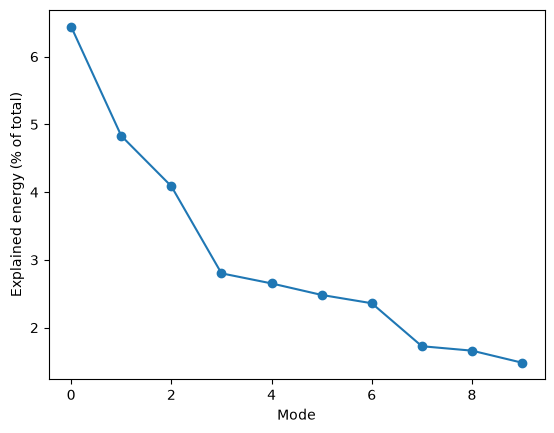

In [19]:
plt.plot(pod.explained_energy_ratio*100, "o-")
plt.xlabel("Mode")
plt.ylabel("Explained energy (% of total)")
plt.show()

In [ ]:
print(
    "Together, the 10 modes explain "
    f"{np.sum(pod.explained_energy_ratio) * 100:.1f}% "
    "of the total in-plane (ux, uy) fluctuation energy."
)


Together, the 10 modes explain 30.5% of the total in-plane (ux, uy) fluctuation energy.


Unstack the `samples` dimension of the modes so that we return to the original dimensions `variable` and `point`.

In [21]:
modes = pod.modes.unstack()

In [22]:
modes

<xarray.DataArray 'svd_u' (components: 10, variable: 2, point: 205616)> Size: 16MB
array([[[ 1.81308205e-05,  2.20874972e-05,  3.22441738e-05, ...,
          4.34739159e-05,  4.08354681e-05,  3.82593244e-05],
        [-2.73017140e-05, -2.68134063e-05, -2.34322724e-05, ...,
         -4.22190969e-05, -3.96436735e-05, -3.73048024e-05]],

       [[-1.85637255e-05, -2.08574529e-05, -2.24844789e-05, ...,
         -3.11918711e-06, -3.92446145e-06, -4.50498965e-06],
        [-6.07960101e-06, -1.01531377e-05, -1.52970897e-05, ...,
          2.39301971e-05,  2.22380168e-05,  2.06606128e-05]],

       [[-3.52721618e-05, -3.53720825e-05, -3.72103750e-05, ...,
         -3.45143744e-05, -3.29860050e-05, -3.15632678e-05],
        [ 1.99822352e-07,  3.07279879e-06,  8.43271118e-06, ...,
          3.51334274e-05,  3.39435355e-05,  3.26975642e-05]],

       ...,

       [[-1.65523670e-05, -1.29348873e-05, -6.19835873e-06, ...,
          1.03088641e-05,  1.09591938e-05,  1.12274238e-05],
        [-1.90588507e-05, -1.45063786e-05, -4.78660877e-06, ...,
         -1.24826292e-05, -1.17861655e-05, -1.11503223e-05]],

       [[ 9.31444447e-06,  1.06725602e-05,  9.21983883e-06, ...,
         -1.66632672e-05, -1.42382860e-05, -1.19885553e-05],
        [ 1.23845239e-05,  1.51395880e-05,  1.52843950e-05, ...,
          5.92686592e-06,  5.14982366e-06,  4.58379054e-06]],

       [[ 2.61762921e-06, -1.63479433e-06, -5.81297490e-06, ...,
          7.58812894e-06,  8.12502003e-06,  8.41786277e-06],
        [ 4.53267558e-06, -2.41308499e-06, -1.13960841e-05, ...,
          1.52322918e-05,  1.23704176e-05,  9.83471728e-06]]],
      shape=(10, 2, 205616), dtype=float32)
Coordinates:
  * components  (components) int64 80B 0 1 2 3 4 5 6 7 8 9
  * variable    (variable) object 16B 'uy' 'ux'
  * point       (point) int64 2MB 23 43 47 50 55 ... 222169 222170 222171 222172
    x           (variable, point) float64 3MB -0.4758 -0.4604 ... 6.031 6.031
    y           (variable, point) float64 3MB -0.9895 -0.9028 ... 0.9013 0.9625
    w           (variable, point) float64 3MB 0.002413 0.002155 ... 0.002301

The plot below shows contour plots of the first four POD modes associated with the x-velocity component.
We can clearly see the oscillatory pattern downstream of the airfoil.

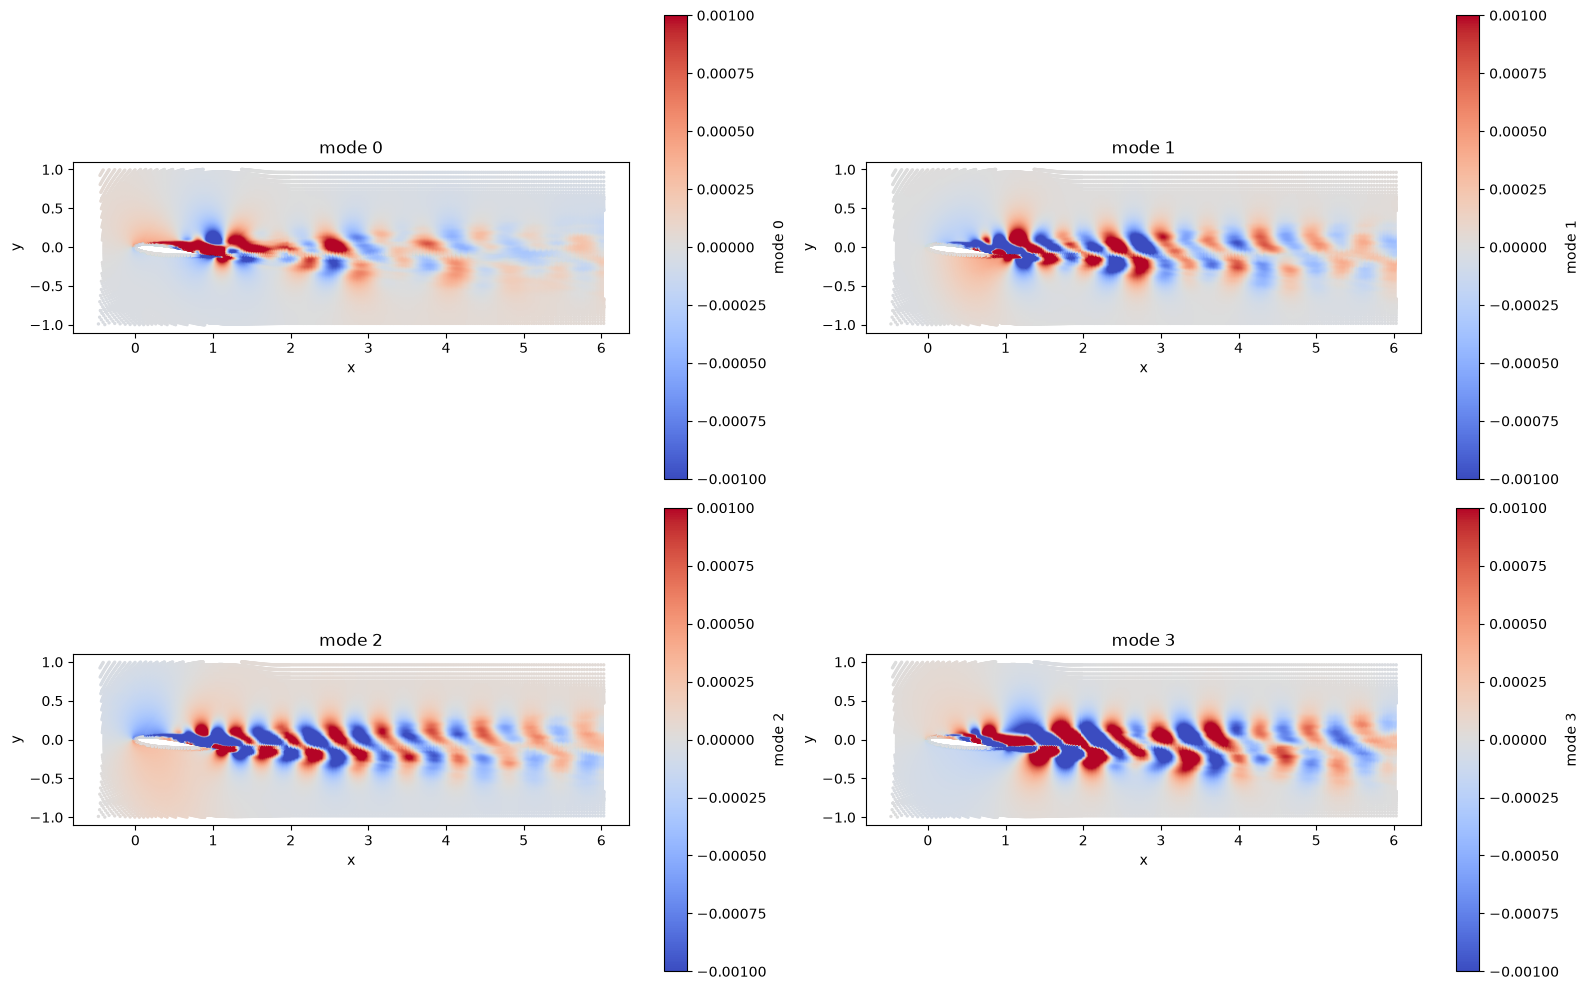

In [23]:
n_modes = 4
x, y = modes["x"].sel(variable="ux"), modes["y"].sel(variable="ux")

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for component, ax in enumerate(axes.flat):
    mode = modes.sel(components=component, variable="ux")
    sc = ax.scatter(x, y, c=mode, s=2, cmap="coolwarm", vmin=-0.001, vmax=0.001)
    fig.colorbar(sc, ax=ax, label=f"mode {component}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(f"mode {component}")
    ax.set_aspect("equal")

fig.tight_layout()
plt.show()

Below we compute and plot the power spectrum of the time coefficients of the first 4 POD modes.
We can identify a clear peak around $St \approx 1.5$, as we did previously in the power spectrum of the y-velocity probe at `x=2, y=0`.
We can also see that some of the spectra show another peak at $St \approx 1$, suggesting that another frequency of oscillation in addition to vortex shedding is present.
This could be from a separated shear layer on the suction side of the airfoil.

Given the definition of the POD in the [docs](https://svdrom.readthedocs.io/en/latest/contents/background.html#proper-orthogonal-decomposition), the time coefficients of a given POD mode inform of how strongly that mode is expressed in each of the flow field snapshots.
Therefore, analyzing the time coefficients is a good way to understand how a given POD mode evolves over time.
However, the fact that two different and dominant frequencies of oscillation are present in the same mode highlights a known limitation of the standard POD analysis: while POD modes are orthogonal and successively maximize variance/energy, there is no guarantee that each mode is monochromatic (single-frequency).
This is because POD is an energy-optimal decomposition, not a spectral one.
In comparison, Dynamic Mode Decomposition (DMD) guarantees by construction that each DMD mode is associated with a single frequency of oscillation.

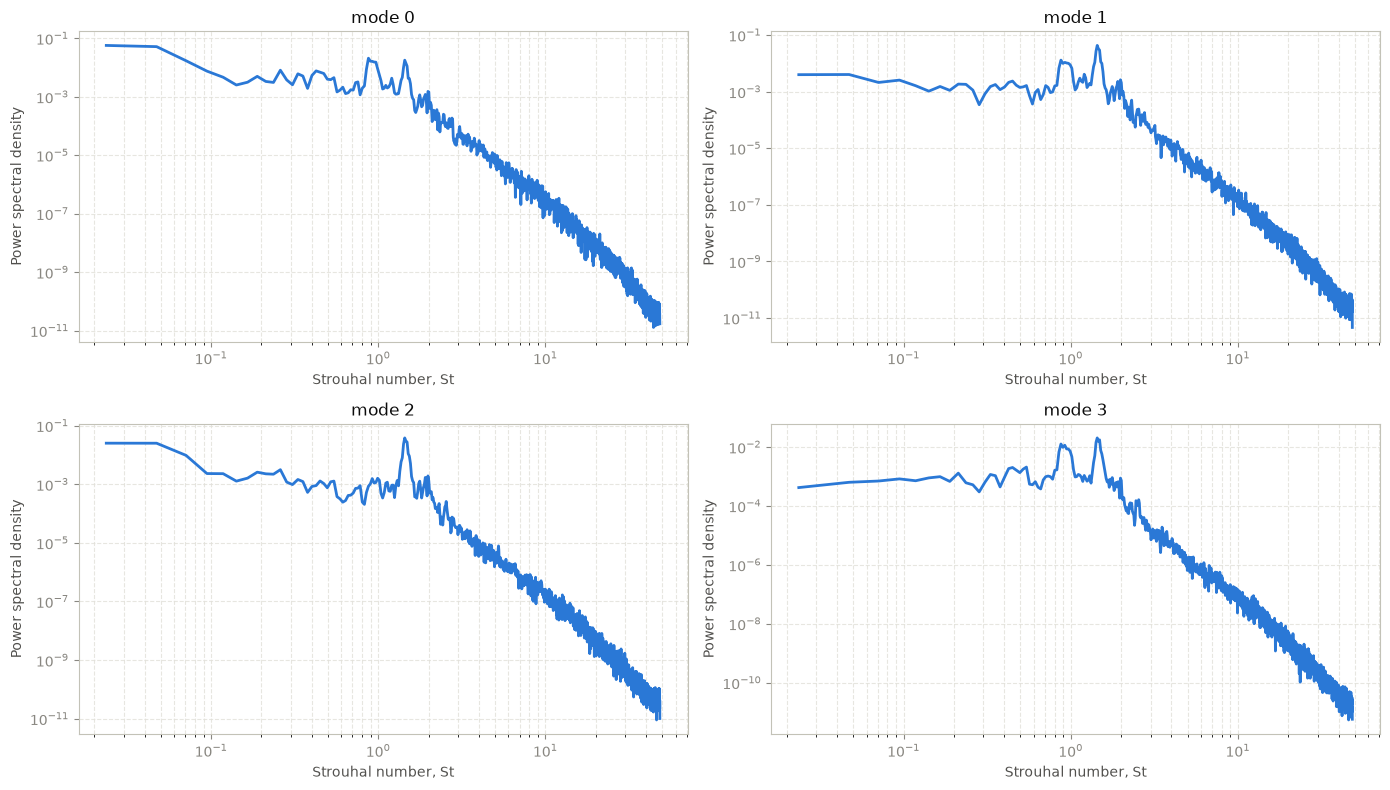

In [24]:
from scipy.signal import welch

t = pod.time_coeffs["time"].values
dt = np.mean(np.diff(t))
fs = 1.0 / dt

n_modes = 4
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for component, ax in enumerate(axes.flat):
    a = pod.time_coeffs.sel(components=component).values
    f, Pxx = welch(a, fs=fs, nperseg=4096)
    ax.loglog(f[1:], Pxx[1:], color="#2a78d6", linewidth=2)
    ax.set_xlabel("Strouhal number, St", color="#52514e")
    ax.set_ylabel("Power spectral density", color="#52514e")
    ax.set_title(f"mode {component}", color="#0b0b0b")
    ax.grid(True, which="both", ls="--", color="#e1e0d9", alpha=0.8)
    ax.tick_params(colors="#898781")
    for spine in ax.spines.values():
        spine.set_color("#c3c2b7")

fig.tight_layout()
plt.show()

## 5. POD reconstruction

Let's animate the x-velocity evolving over time, comparing the original snapshots to the POD reconstruction using the first 10 modes.
For simplicity, we will only reconstruct the first 500 snapshots.

The `reconstruct()` call below will either compute the reconstruction eagerly using NumPy, or will build a lazy Dask task graph, depending on the estimated reconstruction size and the value passed to the parameter `memory_limit_bytes`.
Note that the `POD` class will add back the time average to the reconstruction, so we don't need to worry about that. 

In [25]:
reconstruction = pod.reconstruct(slice(500))
reconstruction = reconstruction.compute()

2026-08-04 13:55 - SVD - INFO - Computing the SVD reconstruction...
2026-08-04 13:55 - SVD - INFO - Estimated reconstruction size is 822464.000 KB.
2026-08-04 13:55 - SVD - INFO - Will not use Dask to compute the reconstruction.
2026-08-04 13:55 - SVD - INFO - Done.


We will now unstack the `samples` dimension and select the x-velocity component.

In [26]:
reconstruction = reconstruction.unstack()

In [27]:
ux_reconstruct = reconstruction.sel(variable="ux")

In [28]:
ux_reconstruct

<xarray.DataArray (time: 500, point: 205616)> Size: 411MB
array([[0.9658409 , 0.9631974 , 0.95683974, ..., 1.0018281 , 1.0018127 ,
        1.0018132 ],
       [0.96570396, 0.96307117, 0.9567461 , ..., 1.0018065 , 1.0017916 ,
        1.0017922 ],
       [0.96557677, 0.9629583 , 0.95667094, ..., 1.0017878 , 1.001774  ,
        1.001775  ],
       ...,
       [0.9654511 , 0.96310693, 0.95714384, ..., 1.001067  , 1.0010903 ,
        1.0011278 ],
       [0.9655333 , 0.96318007, 0.9571951 , ..., 1.0010748 , 1.0010957 ,
        1.0011314 ],
       [0.96562   , 0.9632552 , 0.9572448 , ..., 1.001081  , 1.0010997 ,
        1.0011342 ]], shape=(500, 205616), dtype=float32)
Coordinates:
  * time      (time) float64 4kB 0.0 0.01035 0.0207 ... 5.144 5.154 5.165
  * point     (point) int64 2MB 23 43 47 50 55 ... 222169 222170 222171 222172
    x         (point) float64 2MB -0.4758 -0.4604 -0.458 ... 6.031 6.031 6.031
    y         (point) float64 2MB -0.9895 -0.9028 -0.7032 ... 0.9013 0.9625
    w         (point) float64 2MB 0.002413 0.002155 ... 0.002113 0.002301
    variable  <U2 8B 'ux'

We now subsample the original data in the same spatial and temporal domain.

In [29]:
ux_original = data["ux"].isel(time=slice(500))
y = ux_original.y
mask = ((y >= -1) & (y <= 1)).compute()
ux_original = ux_original.where(mask, drop=True)

In [30]:
ux_original

<xarray.DataArray 'ux' (time: 500, point: 205616)> Size: 411MB
dask.array<where, shape=(500, 205616), dtype=float32, chunksize=(100, 205616), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) float64 4kB 0.0 0.01035 0.0207 0.03105 ... 5.144 5.154 5.165
  * point    (point) int64 2MB 23 43 47 50 55 ... 222169 222170 222171 222172
    x        (point) float64 2MB -0.4758 -0.4604 -0.458 ... 6.031 6.031 6.031
    y        (point) float64 2MB -0.9895 -0.9028 -0.7032 ... 0.9013 0.9625
    w        (point) float64 2MB 0.002413 0.002155 ... 0.002113 0.002301

The cell below generates GIFs of the original dataset and its reconstruction, and saves them to disk.
As before, since the data lives on an unstructured grid, we use a scatter plot for each frame.
We use a common color scale for both animations so they can be compared directly, and subsample the frames (`frame_step`) to keep the GIFs a reasonable size.

The GIFs are saved under `data/airfoilLES/results/`, which is untracked by git.
To have them render when viewing this notebook on GitHub, copy them into the tracked `media/` folder (see the cell after generation).

In [ ]:
import matplotlib.animation as animation

# Bring the (time, point) arrays into memory as plain NumPy arrays.
ux_original_vals = ux_original.transpose("time", "point").values
ux_reconstruct_vals = ux_reconstruct.transpose("time", "point").values

x, y = ux_original.x.values, ux_original.y.values
times = ux_original.time.values

# Use a common color scale (based on the original data)
# so both animations are comparable.
vmin, vmax = np.percentile(ux_original_vals, [1, 99])

frame_step = 10  # subsample frames to keep the GIFs a reasonable size
fps = 10
frames = range(0, len(times), frame_step)


def make_scatter_gif(values, filename, title):
    fig, ax = plt.subplots(figsize=(10, 6))
    sc = ax.scatter(x, y, c=values[0], s=2, cmap="viridis", vmin=vmin, vmax=vmax)
    fig.colorbar(sc, ax=ax, label="ux")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_aspect("equal")
    title_artist = ax.set_title(f"{title} @ t={times[0]:.2f}")

    def update(i):
        idx = frames[i]
        sc.set_array(values[idx])
        title_artist.set_text(f"{title} @ t={times[idx]:.2f}")
        return sc, title_artist

    ani = animation.FuncAnimation(fig, update, frames=len(frames), blit=False)
    ani.save(filename, writer=animation.PillowWriter(fps=fps))
    plt.close(fig)


make_scatter_gif(
    ux_original_vals,
    "data/airfoilLES/results/ux_original.gif",
    "Original x-velocity",
)
make_scatter_gif(
    ux_reconstruct_vals,
    "data/airfoilLES/results/ux_reconstruct.gif",
    "Reconstructed x-velocity",
)

Before running the cell below, copy the two GIFs generated above into `media/` (this notebook's directory). Run this from the `demos/` directory:

```bash
cp data/airfoilLES/results/ux_original.gif data/airfoilLES/results/ux_reconstruct.gif media/
```


The cell below shows the GIFs we created side by side.
We can see that the 10 mode POD model does a good job at reconstructing the vortex shedding behind the airfoil, while filtering out all the smaller scale motions.

In [1]:
from IPython.display import HTML

HTML(
    """
<div style="display: flex; gap: 16px;">
    <div style="text-align: center;">
        <p>Original</p>
        <img src="media/ux_original.gif" width="600">
    </div>
    <div style="text-align: center;">
        <p>POD reconstruction (10 modes)</p>
        <img src="media/ux_reconstruct.gif" width="600">
    </div>
</div>
"""
)

It's good practice to shut down the Dask client once we are done with calculations.

In [33]:
client.close()

## 6. Conclusion

In this notebook we have shown how to fit a low-order Proper Orthogonal Decomposition (POD) model to the turbulent wake behind an airfoil.
POD is essentially another name for Principal Component Analysis, but the term POD is more commonly used when dealing with spatio-temporal datasets such as this one.
The dataset on which we fitted the POD was approximately 25 GB in size, and we were able to compute the model in well under 10 minutes on a 8 core, 32 GB machine. The `POD` class also allows to very easily reconstruct the dataset using the fitted reduced order model.